In [15]:
import numpy as np
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import re
import csv
from sklearn.feature_extraction.text import CountVectorizer
%matplotlib inline

In [16]:
os.chdir('/Users/Mark/Documents/Pandas Data/GWF Autocratic Regimes 1.2')

In [17]:
pwd

'/Users/Mark/Documents/Pandas Data/GWF Autocratic Regimes 1.2'

In [18]:
ls

clean.do
GWF All Political Regimes Case List.xls
GWF Autocratic Regimes.xlsx
GWF Codebook.pdf
GWF_AllPoliticalRegimes.dta
GWF_AllPoliticalRegimes.txt
GWFcases.dta
GWFtscs.dta
GWFtscs.txt
README.tex
UPDATES.tex


In [19]:
# The dataset we're using is from a 2014 paper by Geddes, Wright and Frantz (GWF)
# It contains entries for regimes they identify as autocracies between 1946 and 2010

autocracy_excel = pd.ExcelFile('GWF Autocratic Regimes.xlsx')

In [20]:
autocracy_excel.sheet_names

['Autocratic Regimes Case List', 'Tables for Code book', 'TSCS data']

In [21]:
# Reading in the main dataset of autocracies
df = pd.read_excel(autocracy_excel, sheet_name='Autocratic Regimes Case List')
df

,cowcode,gwf_country,gwf_casename,gwf_startdate,gwf_enddate,gwf_startyr,gwf_endyr,gwf_subsreg,gwf_howend,gwf_violent,gwf_regimetype
0,700,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,1930,1973.0,2,5,2,monarchy
1,700,Afghanistan,Afghanistan 73-78,17/07/1973,27/04/1978,1974,1978.0,2,5,4,personal
2,700,Afghanistan,Afghanistan 78-92,27/04/1978,16/04/1992,1979,1992.0,3,6,4,party-personal
3,700,Afghanistan,Afghanistan 96-01,27/09/1996,13/11/2001,1997,2001.0,3,7,4,party-based
4,700,Afghanistan,Afghanistan 09-NA,20/08/2009,31/12/2010,2010,NaN,0,0,0,personal
...,...,...,...,...,...,...,...,...,...,...,...
275,680,Yemen South,Yemen South 67-90,30/11/1967,22/05/1990,1968,1990.0,3,9,1,party-based
276,345,Yugoslavia,Yugoslavia 45-90,1945-07-03 00:00:00,20/01/1990,1946,1990.0,3,9,4,party-based
277,551,Zambia,Zambia 67-91,28/02/1967,31/10/1991,1968,1991.0,1,2,1,party-based
278,551,Zambia,Zambia 96-NA,28/05/1996,31/12/2010,1997,NaN,0,0,0,party-based


In [22]:
# Some general information on the dataframe

print("\n📊 Shape of dataset:", df.shape)

print("\n📑 Column names:")
print(df.columns.tolist())

print("\n📋 Data types:")
print(df.dtypes)

print("\n📊 Missing values per column:")
print(df.isna().sum())

print("\n📋 Unique values:")
print(df.nunique())


📊 Shape of dataset: (280, 11)

📑 Column names:
['cowcode', 'gwf_country', 'gwf_casename', 'gwf_startdate', 'gwf_enddate', 'gwf_startyr', 'gwf_endyr', 'gwf_subsreg', 'gwf_howend', 'gwf_violent', 'gwf_regimetype']

📋 Data types:
cowcode             int64
gwf_country        object
gwf_casename       object
gwf_startdate      object
gwf_enddate        object
gwf_startyr         int64
gwf_endyr         float64
gwf_subsreg         int64
gwf_howend          int64
gwf_violent         int64
gwf_regimetype     object
dtype: object

📊 Missing values per column:
cowcode            0
gwf_country        0
gwf_casename       0
gwf_startdate      0
gwf_enddate        0
gwf_startyr        0
gwf_endyr         57
gwf_subsreg        0
gwf_howend         0
gwf_violent        0
gwf_regimetype     1
dtype: int64

📋 Unique values:
cowcode           118
gwf_country       120
gwf_casename      280
gwf_startdate     276
gwf_enddate       223
gwf_startyr        85
gwf_endyr          64
gwf_subsreg         4
gwf_

In [23]:
# Reading in the auxiliary dataset with more variables and a row for each 'year-regime' pair
tscs_df = pd.read_excel(autocracy_excel, sheet_name='TSCS data')
tscs_df

,cowcode,year,gwf_country,gwf_casename,gwf_startdate,gwf_enddate,gwf_spell,gwf_duration,gwf_fail,gwf_fail_subsregime,gwf_fail_type,gwf_fail_violent,gwf_regimetype,gwf_party,gwf_personal,gwf_military,gwf_monarch
0,40,1953,Cuba,Cuba 52-59,1952-10-03 00:00:00,1959-01-01 00:00:00,7,1,0,0,0,0,personal,0,1,0,0
1,40,1954,Cuba,Cuba 52-59,1952-10-03 00:00:00,1959-01-01 00:00:00,7,2,0,0,0,0,personal,0,1,0,0
2,40,1955,Cuba,Cuba 52-59,1952-10-03 00:00:00,1959-01-01 00:00:00,7,3,0,0,0,0,personal,0,1,0,0
3,40,1956,Cuba,Cuba 52-59,1952-10-03 00:00:00,1959-01-01 00:00:00,7,4,0,0,0,0,personal,0,1,0,0
4,40,1957,Cuba,Cuba 52-59,1952-10-03 00:00:00,1959-01-01 00:00:00,7,5,0,0,0,0,personal,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,850,1995,Indonesia,Indonesia 66-99,1966-11-03 00:00:00,1999-07-06 00:00:00,33,29,0,0,0,0,party-personal-military,1,0,0,0
4587,850,1996,Indonesia,Indonesia 66-99,1966-11-03 00:00:00,1999-07-06 00:00:00,33,30,0,0,0,0,party-personal-military,1,0,0,0
4588,850,1997,Indonesia,Indonesia 66-99,1966-11-03 00:00:00,1999-07-06 00:00:00,33,31,0,0,0,0,party-personal-military,1,0,0,0
4589,850,1998,Indonesia,Indonesia 66-99,1966-11-03 00:00:00,1999-07-06 00:00:00,33,32,0,0,0,0,party-personal-military,1,0,0,0


In [24]:
print("\n📊 Shape of dataset:", tscs_df.shape)

print("\n📑 Column names:")
print(tscs_df.columns.tolist())

print("\n📋 Data types:")
print(tscs_df.dtypes)

print("\n📊 Missing values per column:")
print(tscs_df.isna().sum())

print("\n📋 Unique values:")
print(tscs_df.nunique())


📊 Shape of dataset: (4591, 17)

📑 Column names:
['cowcode', 'year', 'gwf_country', 'gwf_casename', 'gwf_startdate', 'gwf_enddate', 'gwf_spell', 'gwf_duration', 'gwf_fail', 'gwf_fail_subsregime', 'gwf_fail_type', 'gwf_fail_violent', 'gwf_regimetype', 'gwf_party', 'gwf_personal', 'gwf_military', 'gwf_monarch']

📋 Data types:
cowcode                 int64
year                    int64
gwf_country            object
gwf_casename           object
gwf_startdate          object
gwf_enddate            object
gwf_spell               int64
gwf_duration            int64
gwf_fail                int64
gwf_fail_subsregime     int64
gwf_fail_type           int64
gwf_fail_violent        int64
gwf_regimetype         object
gwf_party               int64
gwf_personal            int64
gwf_military            int64
gwf_monarch             int64
dtype: object

📊 Missing values per column:
cowcode                 0
year                    0
gwf_country             0
gwf_casename            0
gwf_startdate   

In [25]:
tscs_df[tscs_df['gwf_country']=='Afghanistan']

,cowcode,year,gwf_country,gwf_casename,gwf_startdate,gwf_enddate,gwf_spell,gwf_duration,gwf_fail,gwf_fail_subsregime,gwf_fail_type,gwf_fail_violent,gwf_regimetype,gwf_party,gwf_personal,gwf_military,gwf_monarch
3625,700,1946,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,17,0,0,0,0,monarchy,0,0,0,1
3626,700,1947,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,18,0,0,0,0,monarchy,0,0,0,1
3627,700,1948,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,19,0,0,0,0,monarchy,0,0,0,1
3628,700,1949,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,20,0,0,0,0,monarchy,0,0,0,1
3629,700,1950,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,21,0,0,0,0,monarchy,0,0,0,1
3630,700,1951,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,22,0,0,0,0,monarchy,0,0,0,1
3631,700,1952,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,23,0,0,0,0,monarchy,0,0,0,1
3632,700,1953,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,24,0,0,0,0,monarchy,0,0,0,1
3633,700,1954,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,25,0,0,0,0,monarchy,0,0,0,1
3634,700,1955,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,26,0,0,0,0,monarchy,0,0,0,1


In [26]:
# We will now collapse this dataset to one row per case study to prepare for merger with the main dataframe
# We are leaving only the rows for the last year of any regime's existence

tscs_df = (
    tscs_df
    .loc[tscs_df.groupby('gwf_casename')['year'].idxmax()]
    .reset_index(drop=True)
)
tscs_df

,cowcode,year,gwf_country,gwf_casename,gwf_startdate,gwf_enddate,gwf_spell,gwf_duration,gwf_fail,gwf_fail_subsregime,gwf_fail_type,gwf_fail_violent,gwf_regimetype,gwf_party,gwf_personal,gwf_military,gwf_monarch
0,700,2010,Afghanistan,Afghanistan 09-NA,20/08/2009,31/12/2010,1,1,0,0,0,0,personal,0,1,0,0
1,700,1973,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,44,44,1,2,5,2,monarchy,0,0,0,1
2,700,1978,Afghanistan,Afghanistan 73-78,17/07/1973,27/04/1978,5,5,1,2,5,4,personal,0,1,0,0
3,700,1992,Afghanistan,Afghanistan 78-92,27/04/1978,16/04/1992,14,14,1,3,6,4,party-personal,1,0,0,0
4,700,2001,Afghanistan,Afghanistan 96-01,27/09/1996,13/11/2001,5,5,1,3,7,4,party-based,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,680,1990,Yemen South,Yemen South 67-90,30/11/1967,22/05/1990,23,23,1,3,9,1,party-based,1,0,0,0
276,345,1990,Yugoslavia,Yugoslavia 45-90,1945-07-03 00:00:00,20/01/1990,45,45,1,3,9,4,party-based,1,0,0,0
277,551,1991,Zambia,Zambia 67-91,28/02/1967,31/10/1991,24,24,1,1,2,1,party-based,1,0,0,0
278,551,2010,Zambia,Zambia 96-NA,28/05/1996,31/12/2010,14,14,0,0,0,0,party-based,1,0,0,0


In [27]:
# Completing the merger on the 'gwf_casename' column
# 'Left' merger ensures that only those regimes in the main DataFrame will be mapped to
# Although the dimensions of the collapsed tscs_df suggest every regime is present in both dataframes

merged_df = df.merge(tscs_df, on='gwf_casename', how='left', suffixes=('', '_y'))
merged_df = merged_df.drop(columns=merged_df.filter(regex='_y$').columns)
merged_df

,cowcode,gwf_country,gwf_casename,gwf_startdate,gwf_enddate,gwf_startyr,gwf_endyr,gwf_subsreg,gwf_howend,gwf_violent,...,gwf_spell,gwf_duration,gwf_fail,gwf_fail_subsregime,gwf_fail_type,gwf_fail_violent,gwf_party,gwf_personal,gwf_military,gwf_monarch
0,700,Afghanistan,Afghanistan 29-73,1929-10-10 00:00:00,17/07/1973,1930,1973.0,2,5,2,...,44,44,1,2,5,2,0,0,0,1
1,700,Afghanistan,Afghanistan 73-78,17/07/1973,27/04/1978,1974,1978.0,2,5,4,...,5,5,1,2,5,4,0,1,0,0
2,700,Afghanistan,Afghanistan 78-92,27/04/1978,16/04/1992,1979,1992.0,3,6,4,...,14,14,1,3,6,4,1,0,0,0
3,700,Afghanistan,Afghanistan 96-01,27/09/1996,13/11/2001,1997,2001.0,3,7,4,...,5,5,1,3,7,4,1,0,0,0
4,700,Afghanistan,Afghanistan 09-NA,20/08/2009,31/12/2010,2010,NaN,0,0,0,...,1,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,680,Yemen South,Yemen South 67-90,30/11/1967,22/05/1990,1968,1990.0,3,9,1,...,23,23,1,3,9,1,1,0,0,0
276,345,Yugoslavia,Yugoslavia 45-90,1945-07-03 00:00:00,20/01/1990,1946,1990.0,3,9,4,...,45,45,1,3,9,4,1,0,0,0
277,551,Zambia,Zambia 67-91,28/02/1967,31/10/1991,1968,1991.0,1,2,1,...,24,24,1,1,2,1,1,0,0,0
278,551,Zambia,Zambia 96-NA,28/05/1996,31/12/2010,1997,NaN,0,0,0,...,14,14,0,0,0,0,1,0,0,0


In [28]:
merged_df.columns.tolist()

['cowcode',
 'gwf_country',
 'gwf_casename',
 'gwf_startdate',
 'gwf_enddate',
 'gwf_startyr',
 'gwf_endyr',
 'gwf_subsreg',
 'gwf_howend',
 'gwf_violent',
 'gwf_regimetype',
 'year',
 'gwf_spell',
 'gwf_duration',
 'gwf_fail',
 'gwf_fail_subsregime',
 'gwf_fail_type',
 'gwf_fail_violent',
 'gwf_party',
 'gwf_personal',
 'gwf_military',
 'gwf_monarch']

In [30]:
# Let us study how the longevity ('spell') of a regime affects the violence with which it is overthrown
# by constructing a violin plot of violence categories against the duration

# The codebook from GWF tells us the coded values for the gwf_fail_violent variable
violence_labels = {
    1: 'No deaths',
    2: '1–25 deaths',
    3: '26–1000 deaths',
    4: '>1000 deaths'
}

# We are using the codebook to filter out the regimes which were still in power in 2010 (for which gwf_fail_violent == 0)

viol_df = (
    merged_df[['gwf_casename', 'gwf_spell', 'gwf_fail_violent']]
    .copy()
    .dropna(subset=['gwf_fail_violent', 'gwf_spell'])
    .query('gwf_fail_violent != 0')
    .assign(violence_cat=lambda x: x['gwf_fail_violent'].map(violence_labels))
)
viol_df

,gwf_casename,gwf_spell,gwf_fail_violent,violence_cat
0,Afghanistan 29-73,44,2,1–25 deaths
1,Afghanistan 73-78,5,4,>1000 deaths
2,Afghanistan 78-92,14,4,>1000 deaths
3,Afghanistan 96-01,5,4,>1000 deaths
5,Albania 44-91,47,2,1–25 deaths
...,...,...,...,...
272,Yemen 67-74,7,1,No deaths
273,Yemen 74-78,4,1,No deaths
275,Yemen South 67-90,23,1,No deaths
276,Yugoslavia 45-90,45,4,>1000 deaths


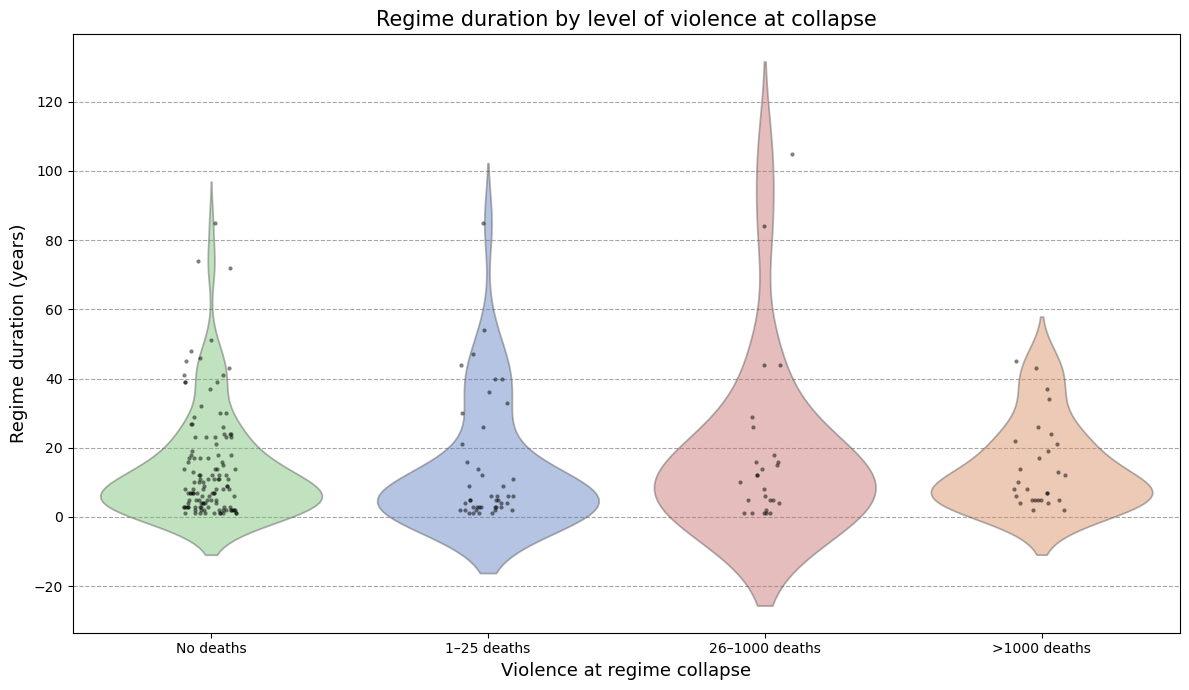

In [31]:
# Preserve the natural ordering on the x-axis
category_order = ['No deaths', '1–25 deaths', '26–1000 deaths', '>1000 deaths']

fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    data=viol_df,
    x='violence_cat',
    y='gwf_spell',
    hue='violence_cat',
    order=category_order,
    inner=None,
    alpha=0.45,
    palette='muted',
    legend=False,
    ax=ax
)
sns.stripplot(
    data=viol_df,
    x='violence_cat',
    y='gwf_spell',
    order=category_order,
    color='black',
    size=3,
    alpha=0.5,
    jitter=True,
    ax=ax
)

ax.set_xlabel('Violence at regime collapse', fontsize=13)
ax.set_ylabel('Regime duration (years)', fontsize=13)
ax.set_title('Regime duration by level of violence at collapse', fontsize=15)
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='grey')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [32]:
# Not very informative, apart from the observation that:
# 1) A small minority of regime collapse cases end in 26-1000 deaths, most of them involve little-to-no violence, 
# with a few being very violent
# 2) There are comparatively few statistical outliers in terms of longevity for the '>1000 deaths' category,
# although it might not be statistically significant due to the small number of elements in the most 'violent' group
# Let us check the visuals by counting the number of cases in each violence group:

viol_df['violence_cat'].value_counts()

violence_cat
No deaths         125
1–25 deaths        44
>1000 deaths       28
26–1000 deaths     26
Name: count, dtype: int64

In [33]:
# Indeed, '26–1000 deaths' is the least numerous category, with '>1000 deaths' being a close second

# Now we are creating a heatmap to see what proportion of each 'spell' group is occupied by each violence group 
# First we're creating a new column with categories for the spell of regimes: 0-5 yrs, 6-15, 16-30, and 30+ yrs.

merged_df['spell_bin'] = pd.cut(
    merged_df['gwf_spell'],
    bins=[0, 5, 15, 30, 100],
    labels=['0–5 yrs', '6–15 yrs', '16–30 yrs', '30+ yrs']
)
merged_df['spell_bin'].value_counts()

spell_bin
0–5 yrs      90
6–15 yrs     72
16–30 yrs    60
30+ yrs      56
Name: count, dtype: int64

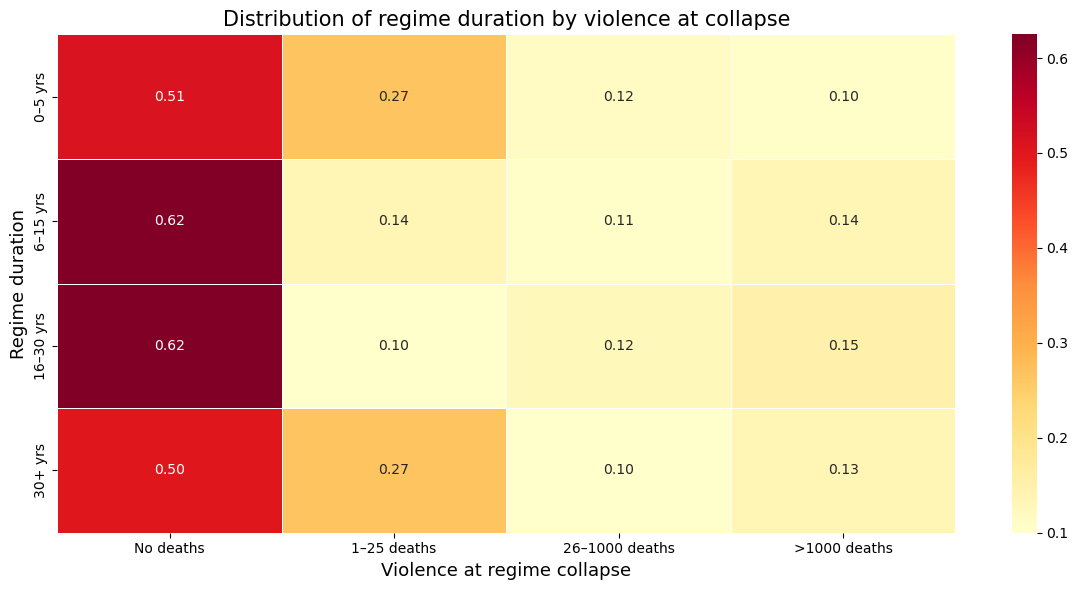

In [34]:
# Not perfect but a reasonably even distribution

heat_df = merged_df[merged_df['gwf_fail_violent'] != 0].copy()
heat_df['violence_cat'] = heat_df['gwf_fail_violent'].map(violence_labels)

# Creates a normalized frequency dataframe, with values representing a proportion of a violence category within a spell bin
ct = pd.crosstab(
    heat_df['spell_bin'],
    heat_df['violence_cat'],
    normalize='index'
)[category_order]

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)

ax.set_xlabel('Violence at regime collapse', fontsize=13)
ax.set_ylabel('Regime duration', fontsize=13)
ax.set_title('Distribution of regime duration by violence at collapse', fontsize=15)

plt.tight_layout()
plt.show()

In [35]:
# A little more interesting:
# No clear pattern at the more 'violent' end of the spectrum
# But the very short-lived (0-5 yrs) and very aged (30+ yrs) regimes are somewhat more likely 
# to have a completely non-violent transition than the regimes in the range 6-30 yrs (0.50/0.51 against 0.62).
# Conversely, those 'middle-aged' regimes are ostensibly less likely
# to have a 'moderate violence' scenario with 1-25 deaths than the 0-5 and 30+ groups (0.10/0.14 against 0.27).

In [36]:
# Now, we will take a look at the likelihoods for each level of regime collapse violence
# to subsequently lead to a democracy/autocracy/state collapse

# Again from the codebook:
subs_labels = {
    1: 'Democracy',
    2: 'Autocracy',
    3: 'Warlord/Occupied/Collapsed'
}

subs_df = (
    merged_df[['gwf_casename', 'gwf_spell', 'gwf_fail_violent', 'gwf_fail_subsregime']]
    .copy()
    .dropna(subset=['gwf_fail_violent', 'gwf_fail_subsregime'])
    .query('gwf_fail_violent != 0 and gwf_fail_subsregime != 0')
    .assign(
        violence_cat=lambda x: x['gwf_fail_violent'].map(violence_labels),
        subs_cat=lambda x: x['gwf_fail_subsregime'].map(subs_labels)
    )
)
subs_df

,gwf_casename,gwf_spell,gwf_fail_violent,gwf_fail_subsregime,violence_cat,subs_cat
0,Afghanistan 29-73,44,2,2,1–25 deaths,Autocracy
1,Afghanistan 73-78,5,4,2,>1000 deaths,Autocracy
2,Afghanistan 78-92,14,4,3,>1000 deaths,Warlord/Occupied/Collapsed
3,Afghanistan 96-01,5,4,3,>1000 deaths,Warlord/Occupied/Collapsed
5,Albania 44-91,47,2,1,1–25 deaths,Democracy
...,...,...,...,...,...,...
272,Yemen 67-74,7,1,2,No deaths,Autocracy
273,Yemen 74-78,4,1,2,No deaths,Autocracy
275,Yemen South 67-90,23,1,3,No deaths,Warlord/Occupied/Collapsed
276,Yugoslavia 45-90,45,4,3,>1000 deaths,Warlord/Occupied/Collapsed


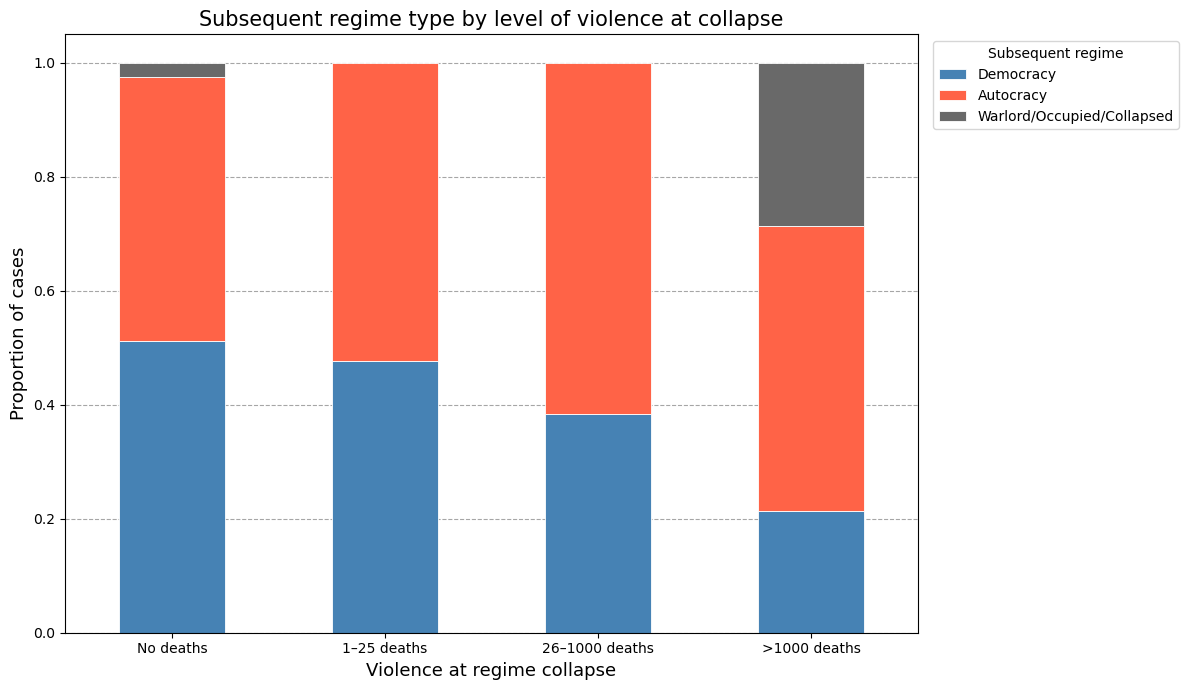

In [37]:
ct = pd.crosstab(
    subs_df['violence_cat'],
    subs_df['subs_cat'],
    normalize='index'
)[['Democracy', 'Autocracy', 'Warlord/Occupied/Collapsed']]

ct = ct.reindex(category_order)

fig, ax = plt.subplots(figsize=(12, 7))

ct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['steelblue', 'tomato', 'dimgrey'],
    edgecolor='white',
    linewidth=0.6
)

ax.set_xlabel('Violence at regime collapse', fontsize=13)
ax.set_ylabel('Proportion of cases', fontsize=13)
ax.set_title('Subsequent regime type by level of violence at collapse', fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Subsequent regime', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='grey')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [38]:
# A highly interesting bar chart
# As the regime collapse becomes more violent, the likelihood of it being followed by a democracy falls noticably
# For very violent cases (>1000 deaths), democracy barely emerges 20% of the time
# Even more interestingly, almost all cases of state collapse/foreign occupation
# are concentrated in that 'most violent' (>1000 deaths) group